FIRST 5 ROWS:
  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

    Join_Date     Salary                       Email       Phone  \
0    4/2/2021   59767.65       bob.davis@example.com -1651623197   
1   7/10/2020   65304.66       bob.brown@example.com -1898471390   
2   12/7/2023   88145.90     alice.jones@example.com -5596363211   
3  11/27/2021   69450.99       eva.davis@example.com -3476490784   
4    1/5/2022  109324.61  frank.williams@example.com -1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good        

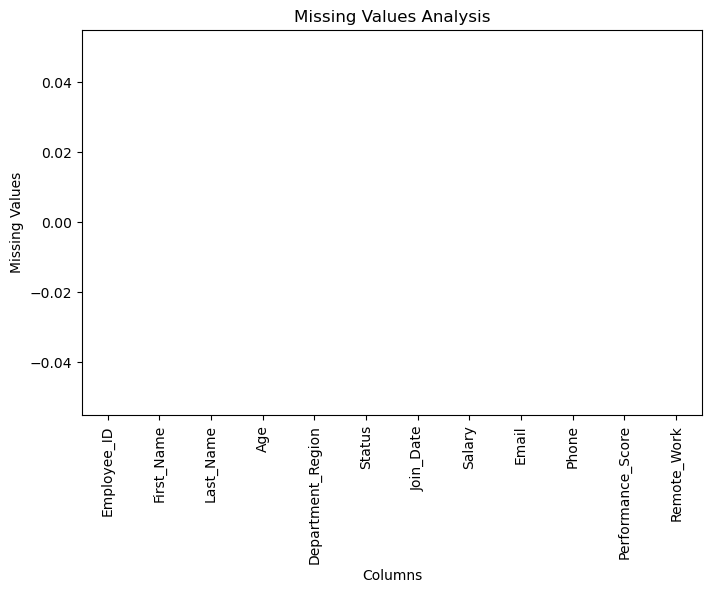


FILES GENERATED SUCCESSFULLY
1. Cleaned_Employee_Data.csv
2. Automation_Report.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Messy_Employee_dataset.csv")

print("FIRST 5 ROWS:")
print(df.head())

print("\nDATASET INFO:")
print(df.info())

print("\nMISSING VALUES:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()

print("\nDUPLICATES:", duplicate_count)

df.drop_duplicates(inplace=True)

for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].astype(str).str.strip().str.title()

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())
for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].fillna("Unknown")

if 'Salary' in df.columns:
    df = df[df['Salary'] >= 0]

if 'Age' in df.columns:
    df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]

missing_after = df.isnull().sum().sum()

print("\nTOTAL REMAINING MISSING VALUES:", missing_after)

total_rows = len(df)

quality_score = ((total_rows - missing_after) / total_rows) * 100

print("\nDATA QUALITY SCORE:", round(quality_score,2), "%")

summary = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Duplicates Removed',
        'Remaining Missing Values',
        'Data Quality Score'
    ],
    'Value': [
        total_rows,
        duplicate_count,
        missing_after,
        str(round(quality_score,2)) + '%'
    ]
})

print("\nAUTOMATED SUMMARY REPORT:")
print(summary)

summary.to_csv("Automation_Report.csv", index=False)

df.to_csv("Cleaned_Employee_Data.csv", index=False)

plt.figure(figsize=(8,5))

df.isnull().sum().plot(kind='bar')

plt.title('Missing Values Analysis')

plt.xlabel('Columns')

plt.ylabel('Missing Values')

plt.show()

if 'Department' in df.columns:
    plt.figure(figsize=(8,5))

    df['Department'].value_counts().plot(kind='bar')

    plt.title('Department Distribution')

    plt.xlabel('Department')

    plt.ylabel('Count')

    plt.show()

print("\nFILES GENERATED SUCCESSFULLY")
print("1. Cleaned_Employee_Data.csv")
print("2. Automation_Report.csv")